# HybridSN Exploring 3D-2D 教学 Notebook

这份 Notebook 将 `HybridSN_Exploring_3D_2D/` 目录里的核心方法整理成单个教学 notebook。

这里保留的方法重点是：

- 先在高光谱 patch 上做 **3D 卷积**
- 再把谱域和通道信息重排，交给 **2D 卷积**
- 最后完成高光谱像素分类

它可以看成是 `HybridSN` 的一类典型 3D-2D 联合建模思路。


## 本 Notebook 会完成什么

1. 读取 `Indian Pines`
2. 做 PCA 降维与 patch 提取
3. 构建 `HybridSN Exploring 3D-2D` 网络
4. 训练并记录曲线
5. 评估 OA、AA、Kappa 和分类报告
6. 生成整图预测结果并保存


In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

SEED = 345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

class_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers']


device = cuda


## 1. 读取数据

这里使用 `Indian Pines`，并统一沿用项目里已经使用的 `nipy_spectral` 结果图风格。


In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"].astype(np.float32)
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"].astype(np.int64)

print("cube shape:", cube.shape)
print("gt shape:", gt.shape)
print("num classes:", int(gt.max()))
print("labeled pixels:", int((gt != 0).sum()))


cube shape: (145, 145, 200)
gt shape: (145, 145)
num classes: 16
labeled pixels: 10249


In [3]:
unique, counts = np.unique(gt, return_counts=True)
class_count_df = pd.DataFrame({"label": unique, "count": counts})
class_count_df = class_count_df[class_count_df["label"] != 0].copy()
class_count_df["class_name"] = class_count_df["label"].apply(lambda x: class_names[x - 1])
class_count_df = class_count_df[["label", "class_name", "count"]].sort_values("label")
class_count_df


,label,class_name,count
1,1,Alfalfa,46
2,2,Corn-notill,1428
3,3,Corn-mintill,830
4,4,Corn,237
5,5,Grass-pasture,483
6,6,Grass-trees,730
7,7,Grass-pasture-mowed,28
8,8,Hay-windrowed,478
9,9,Oats,20
10,10,Soybean-notill,972


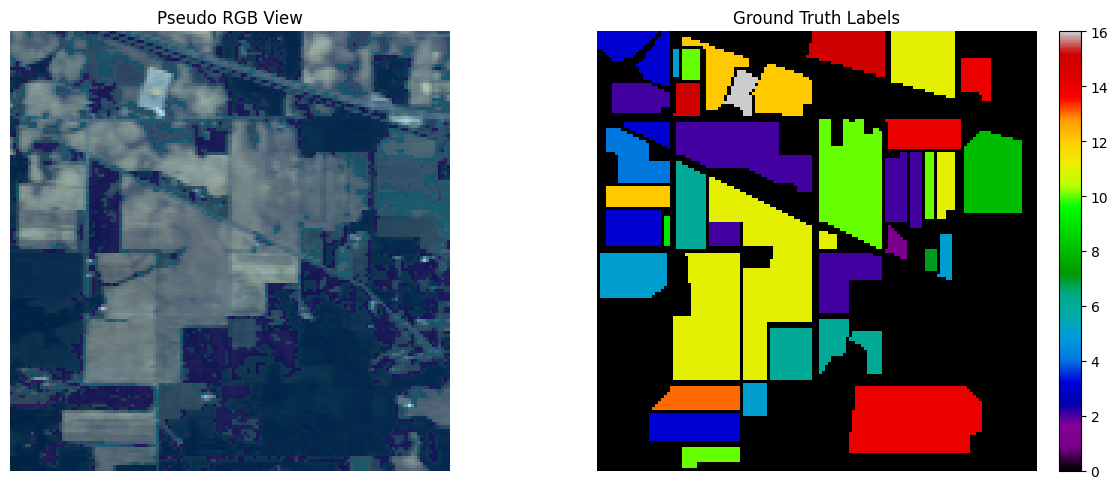

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb = cube[:, :, [29, 19, 9]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB View")
axes[0].axis("off")

im = axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth Labels")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 2. PCA 与 patch 提取

这个目录里的实现使用了：

- `PCA = 30`
- `window_size = 25`
- `test_ratio = 0.7`

这里尽量保留这套设定，并在训练集内部再切一部分验证集，用于保存最优权重。


In [5]:
PCA_COMPONENTS = 30
WINDOW_SIZE = 25
TEST_RATIO = 0.7
VAL_RATIO_WITHIN_TRAIN = 0.2
BATCH_SIZE = 64
EPOCHS = 12
LEARNING_RATE = 1e-3

flat_cube = cube.reshape(-1, cube.shape[2]).astype(np.float32)
pca = PCA(n_components=PCA_COMPONENTS, whiten=True)
pca_cube = pca.fit_transform(flat_cube).astype(np.float32).reshape(cube.shape[0], cube.shape[1], PCA_COMPONENTS)

print("pca cube shape:", pca_cube.shape)
print("explained variance ratio sum:", float(pca.explained_variance_ratio_.sum()))


pca cube shape: (145, 145, 30)
explained variance ratio sum: 0.9924845695495605


In [6]:
def pad_with_zeros(x, margin=2):
    new_x = np.zeros((x.shape[0] + 2 * margin, x.shape[1] + 2 * margin, x.shape[2]), dtype=np.float32)
    new_x[margin:x.shape[0] + margin, margin:x.shape[1] + margin, :] = x
    return new_x


def create_image_cubes(x, y, window_size=5, remove_zero_labels=True):
    margin = (window_size - 1) // 2
    zero_padded_x = pad_with_zeros(x, margin=margin)
    patches_data = np.zeros((x.shape[0] * x.shape[1], window_size, window_size, x.shape[2]), dtype=np.float32)
    patches_labels = np.zeros((x.shape[0] * x.shape[1]), dtype=np.int64)
    patch_index = 0
    for r in range(margin, zero_padded_x.shape[0] - margin):
        for c in range(margin, zero_padded_x.shape[1] - margin):
            patch = zero_padded_x[r - margin:r + margin + 1, c - margin:c + margin + 1]
            patches_data[patch_index, :, :, :] = patch
            patches_labels[patch_index] = y[r - margin, c - margin]
            patch_index += 1
    if remove_zero_labels:
        patches_data = patches_data[patches_labels > 0, :, :, :]
        patches_labels = patches_labels[patches_labels > 0]
        patches_labels -= 1
    return patches_data, patches_labels


X, y = create_image_cubes(pca_cube, gt, window_size=WINDOW_SIZE, remove_zero_labels=True)

print("patch tensor shape before split:", X.shape)
print("label shape:", y.shape)


patch tensor shape before split: (10249, 25, 25, 30)
label shape: (10249,)


In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_RATIO_WITHIN_TRAIN,
    random_state=SEED,
    stratify=y_train_full,
)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)


train: (2459, 25, 25, 30) (2459,)
val:   (615, 25, 25, 30) (615,)
test:  (7175, 25, 25, 30) (7175,)


In [8]:
def count_by_class(labels, class_names):
    values, counts = np.unique(labels, return_counts=True)
    rows = []
    for v, c in zip(values, counts):
        rows.append({"label": int(v + 1), "class_name": class_names[v], "count": int(c)})
    return pd.DataFrame(rows)


split_summary = pd.concat(
    [
        count_by_class(y_train, class_names).assign(split="train"),
        count_by_class(y_val, class_names).assign(split="val"),
        count_by_class(y_test, class_names).assign(split="test"),
    ],
    ignore_index=True,
)
split_summary.head(12)


,label,class_name,count,split
0,1,Alfalfa,11,train
1,2,Corn-notill,342,train
2,3,Corn-mintill,199,train
3,4,Corn,57,train
4,5,Grass-pasture,116,train
5,6,Grass-trees,175,train
6,7,Grass-pasture-mowed,7,train
7,8,Hay-windrowed,114,train
8,9,Oats,5,train
9,10,Soybean-notill,234,train


In [9]:
class HSIDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.from_numpy(x).float()
        self.y = None if y is None else torch.from_numpy(y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        sample = self.x[idx].permute(2, 0, 1).unsqueeze(0)
        if self.y is None:
            return sample
        return sample, self.y[idx]


train_loader = DataLoader(HSIDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(HSIDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(HSIDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)
all_loader = DataLoader(HSIDataset(X, y=None), batch_size=BATCH_SIZE, shuffle=False)

next(iter(train_loader))[0].shape


torch.Size([64, 1, 30, 25, 25])

## 3. 定义 HybridSN Exploring 3D-2D

这里使用 `model_torch.py` 里的主结构思路：

- 连续三层 `Conv3d`
- 将谱域与通道信息合并后交给 `Conv2d`
- 再经过全连接层输出分类结果


In [10]:
class HybridSNExploring(nn.Module):
    def __init__(self, num_classes, patch_size, input_bands):
        super().__init__()

        self.conv3d_1 = nn.Conv3d(1, 8, kernel_size=(7, 3, 3))
        self.conv3d_2 = nn.Conv3d(8, 16, kernel_size=(5, 3, 3))
        self.conv3d_3 = nn.Conv3d(16, 32, kernel_size=(3, 3, 3))
        self.relu = nn.ReLU(inplace=True)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_bands, patch_size, patch_size)
            x = self.relu(self.conv3d_1(dummy))
            x = self.relu(self.conv3d_2(x))
            x = self.relu(self.conv3d_3(x))
            _, c, d, h, w = x.shape
            self.merged_channels = c * d
            self.after_3d_h = h
            self.after_3d_w = w

        self.conv2d = nn.Conv2d(self.merged_channels, 64, kernel_size=3)

        with torch.no_grad():
            dummy2 = torch.zeros(1, self.merged_channels, self.after_3d_h, self.after_3d_w)
            x2 = self.relu(self.conv2d(dummy2))
            flattened_dim = x2.numel()

        self.fc1 = nn.Linear(flattened_dim, 256)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.relu(self.conv3d_1(x))
        x = self.relu(self.conv3d_2(x))
        x = self.relu(self.conv3d_3(x))
        x = x.reshape(x.size(0), x.size(1) * x.size(2), x.size(3), x.size(4))
        x = self.relu(self.conv2d(x))
        x = x.reshape(x.size(0), -1)
        x = self.dropout1(self.relu(self.fc1(x)))
        x = self.dropout2(self.relu(self.fc2(x)))
        return self.fc3(x)


model = HybridSNExploring(len(class_names), WINDOW_SIZE, PCA_COMPONENTS).to(device)
print("model parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
model


model parameters: 5,122,176


HybridSNExploring(
  (conv3d_1): Conv3d(1, 8, kernel_size=(7, 3, 3), stride=(1, 1, 1))
  (conv3d_2): Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(1, 1, 1))
  (conv3d_3): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1))
  (relu): ReLU(inplace=True)
  (conv2d): Conv2d(576, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=18496, out_features=256, bias=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=128, out_features=16, bias=True)
)

In [11]:
@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    total_correct = 0
    total_count = 0

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += yb.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    acc = total_correct / total_count
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return acc, y_true, y_pred


output_dir = Path("results/hybridsn_exploring_3d_2d/IP_notebook")
output_dir.mkdir(parents=True, exist_ok=True)
best_model_path = output_dir / "best_model.pth"

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
}


## 4. 训练模型

这里记录训练损失、训练准确率和验证准确率，并保存验证集最优权重。


In [12]:
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_acc, _, _ = evaluate_model(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

print("best_val_acc =", round(best_val_acc, 4))


Epoch 01/12 | loss=2.4637 | train_acc=0.2090 | val_acc=0.2390


Epoch 02/12 | loss=1.7774 | train_acc=0.3668 | val_acc=0.6455


Epoch 03/12 | loss=0.8711 | train_acc=0.7056 | val_acc=0.8862


Epoch 04/12 | loss=0.4201 | train_acc=0.8723 | val_acc=0.9659


Epoch 05/12 | loss=0.2528 | train_acc=0.9219 | val_acc=0.9724


...

Epoch 08/12 | loss=0.1308 | train_acc=0.9679 | val_acc=0.9789


Epoch 09/12 | loss=0.1010 | train_acc=0.9736 | val_acc=0.9870


Epoch 10/12 | loss=0.0751 | train_acc=0.9809 | val_acc=0.9951


Epoch 11/12 | loss=0.0645 | train_acc=0.9813 | val_acc=0.9935


Epoch 12/12 | loss=0.0442 | train_acc=0.9882 | val_acc=0.9902
best_val_acc = 0.9951


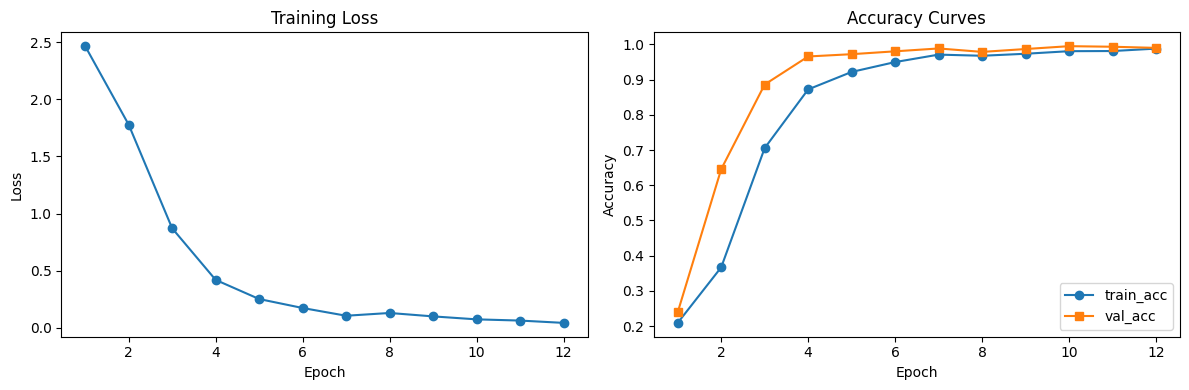

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch_index = np.arange(1, EPOCHS + 1)
axes[0].plot(epoch_index, history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epoch_index, history["train_acc"], marker="o", label="train_acc")
axes[1].plot(epoch_index, history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. 测试集评估


In [14]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

test_acc, y_true_test, y_pred_test = evaluate_model(model, test_loader, device)
oa = accuracy_score(y_true_test, y_pred_test)
aa = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
kappa = cohen_kappa_score(y_true_test, y_pred_test)

print("Test accuracy:", round(test_acc, 4))
print("OA:", round(oa, 4))
print("AA:", round(aa, 4))
print("Kappa:", round(kappa, 4))


Test accuracy: 0.9904
OA: 0.9904
AA: 0.9693
Kappa: 0.989


In [15]:
report = classification_report(
    y_true_test,
    y_pred_test,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report)


                              precision    recall  f1-score   support

                     Alfalfa     1.0000    0.9375    0.9677        32
                 Corn-notill     0.9920    0.9880    0.9900      1000
                Corn-mintill     0.9699    1.0000    0.9847       581
                        Corn     0.9759    0.9759    0.9759       166
               Grass-pasture     0.9879    0.9645    0.9760       338
                 Grass-trees     0.9961    0.9922    0.9941       511
         Grass-pasture-mowed     0.8696    1.0000    0.9302        20
               Hay-windrowed     0.9941    1.0000    0.9970       335
                        Oats     1.0000    0.7857    0.8800        14
              Soybean-notill     1.0000    0.9926    0.9963       680
             Soybean-mintill     0.9948    0.9942    0.9945      1719
               Soybean-clean     0.9831    0.9831    0.9831       415
                       Wheat     0.9859    0.9790    0.9825       143
                   

## 6. 整图预测

这里对全部有标签 patch 做推理，并还原成二维分类图。


In [16]:
@torch.no_grad()
def predict_all(model, data_loader):
    model.eval()
    preds = []
    for xb in data_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


all_pred = predict_all(model, all_loader)
pred_map = np.zeros_like(gt)
labeled_positions = np.argwhere(gt > 0)
for (i, j), pred in zip(labeled_positions, all_pred):
    pred_map[i, j] = pred + 1

print("pred_map shape:", pred_map.shape)
print("nonzero predictions:", int((pred_map != 0).sum()))


pred_map shape: (145, 145)
nonzero predictions: 10249


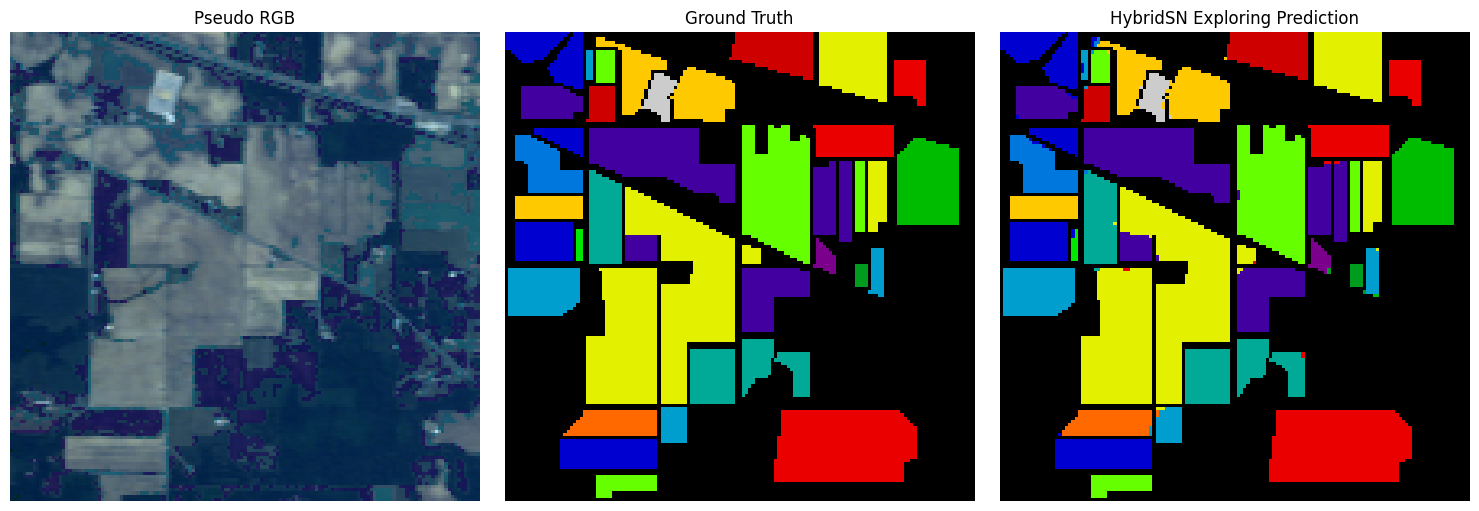

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB")
axes[0].axis("off")

axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[2].set_title("HybridSN Exploring Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 7. 保存结果


In [18]:
metrics = {
    "seed": SEED,
    "pca_components": PCA_COMPONENTS,
    "window_size": WINDOW_SIZE,
    "test_ratio": TEST_RATIO,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "oa": float(oa),
    "aa": float(aa),
    "kappa": float(kappa),
    "best_val_acc": float(best_val_acc),
}

(output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(output_dir / "classification_report.txt").write_text(report, encoding="utf-8")
class_count_df.to_csv(output_dir / "class_distribution.csv", index=False)
split_summary.to_csv(output_dir / "split_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].plot(np.arange(1, EPOCHS + 1), history["train_acc"], marker="o", label="train_acc")
axes[1].plot(np.arange(1, EPOCHS + 1), history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
fig.savefig(output_dir / "training_curves.png", dpi=200)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("HybridSN Exploring Prediction")
axes[1].axis("off")
plt.tight_layout()
fig.savefig(output_dir / "prediction_map.png", dpi=200)
plt.close(fig)

print("saved to", output_dir)
print(sorted(p.name for p in output_dir.iterdir()))


saved to results\hybridsn_exploring_3d_2d\IP_notebook
['best_model.pth', 'class_distribution.csv', 'classification_report.txt', 'metrics.json', 'prediction_map.png', 'split_summary.csv', 'training_curves.png']


## 8. 小结

这份 Notebook 把 `HybridSN_Exploring_3D_2D/` 目录里的核心方法整理成了一个单文件教学流程：

- 用 PCA 压缩光谱维度
- 先做 3D 卷积，再做 2D 卷积
- 输出训练曲线、分类指标和整图预测结果

从理解角度看，它很适合作为“为什么高光谱模型会把 3D 与 2D 卷积接起来”的一个具体例子。
